
# Pneumonia Detection using Deep Learning (ResNet)

This project builds a deep learning model to detect pneumonia from chest X-rays using transfer learning (ResNet).  

**Final Results:**
- Accuracy: 86%
- F1 Score: 0.90
- Recall (Pneumonia): 99%


## 1. Setup & Imports

In [1]:
!pip install -q kaggle grad-cam

import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
cuda


## 2. Download Dataset

In [2]:

# Upload kaggle.json before running

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/data


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:36<00:00, 67.7MB/s]



## 3. Dataset Path

In [3]:

BASE_PATH = "/content/data/chest_xray/chest_xray"


## 4. Data Preprocessing

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


## 5. Data Loaders

In [5]:
train_data = datasets.ImageFolder(BASE_PATH + '/train', transform=train_transform)
val_data = datasets.ImageFolder(BASE_PATH + '/val', transform=eval_transform)
test_data = datasets.ImageFolder(BASE_PATH + '/test', transform=eval_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)


Classes: ['NORMAL', 'PNEUMONIA']


## 6. Handle Class Imbalance

In [6]:
class_counts = Counter(train_data.targets)

weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(len(class_counts))],
    dtype=torch.float32
).to(device)

print("Class Counts:", class_counts)
print("Class Weights:", weights)


Class Counts: Counter({1: 3875, 0: 1341})
Class Weights: tensor([0.0007, 0.0003], device='cuda:0')


## 7. Model (ResNet Transfer Learning)

In [7]:
model = models.resnet18(pretrained=True)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace and train the final classifier
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 76.4MB/s]


## 8. Loss & Optimizer

In [8]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)


## 9. Training & Evaluation Functions

In [9]:
def train(model, loader):
    model.train()
    total_loss = 0
    correct, total = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


## 10. Train Model

Epoch 1/15: Train Loss=0.1255, Train Acc=0.9459, Val Loss=0.5768, Val Acc=0.8125
Epoch 2/15: Train Loss=0.0784, Train Acc=0.9709, Val Loss=0.3350, Val Acc=0.9375
Epoch 3/15: Train Loss=0.0597, Train Acc=0.9760, Val Loss=0.2291, Val Acc=0.9375
Epoch 4/15: Train Loss=0.0380, Train Acc=0.9879, Val Loss=0.1334, Val Acc=0.9375
Epoch 5/15: Train Loss=0.0414, Train Acc=0.9847, Val Loss=0.2343, Val Acc=0.9375
Epoch 6/15: Train Loss=0.0395, Train Acc=0.9862, Val Loss=0.3301, Val Acc=0.9375
Epoch 7/15: Train Loss=0.0286, Train Acc=0.9887, Val Loss=0.2611, Val Acc=0.9375
Early stopping triggered.


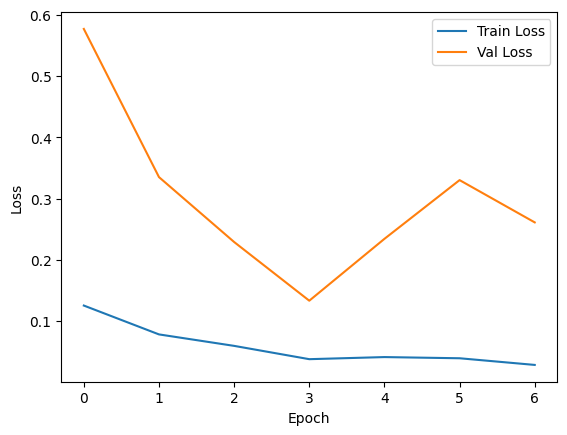

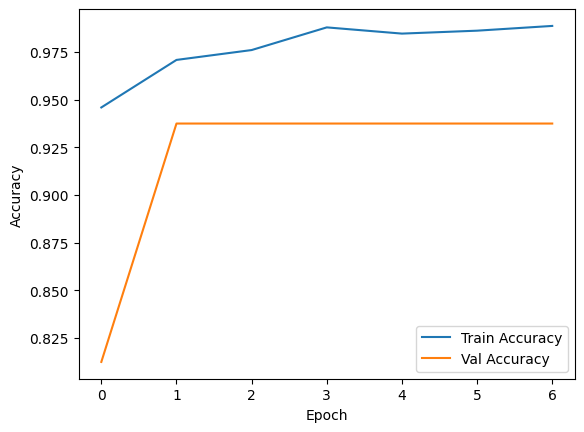

In [10]:
num_epochs = 15
patience = 3

best_val_loss = float('inf')
best_model_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}: "
        f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

# Restore the model with the best validation loss
model.load_state_dict(best_model_state)

plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 11. Test Accuracy

In [11]:
test_loss, test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)


Test Accuracy: 0.8766025641025641


## 12. Detailed Evaluation

In [12]:

from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.96      0.70      0.81       234
           1       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624

[[164  70]
 [  7 383]]


## 13. Grad-CAM Visualization

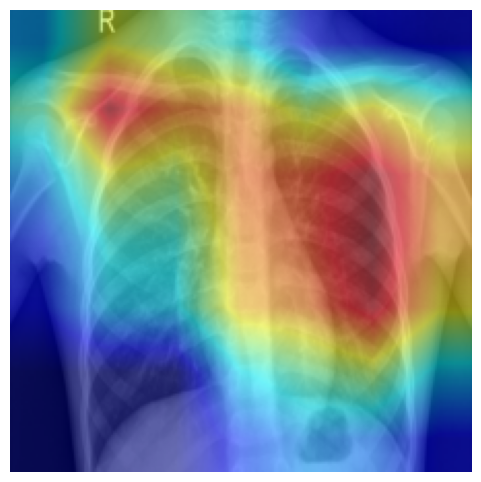

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


# Put model in evaluation mode
model.eval()

# Target layer: last convolutional block of ResNet
target_layer = model.layer4[-1]

# Create Grad-CAM
cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

# Get one batch
images, labels = next(iter(test_loader))
images = images.to(device)

# Get model predictions
with torch.no_grad():
    outputs = model(images)
    predicted_classes = outputs.argmax(dim=1)

# Create targets for Grad-CAM
targets = [
    ClassifierOutputTarget(class_idx.item())
    for class_idx in predicted_classes
]

# Generate Grad-CAM
grayscale_cam = cam(
    input_tensor=images,
    targets=targets
)

# Take first image
img = images[0].cpu().permute(1, 2, 0).numpy()

# Normalize image to [0, 1]
img = (img - img.min()) / (img.max() - img.min())

# Overlay CAM
cam_image = show_cam_on_image(
    img,
    grayscale_cam[0],
    use_rgb=True
)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(cam_image)
plt.axis("off")
plt.show()